# JDR versus classical light-curve features: a self-contained 1,000-star experiment

**Question:** How does the paper-aligned JDR representation compare with classical descriptive/Fourier features when the data and clustering policies are held fixed?

This notebook contains **all analysis and plotting code**, rather than calling hidden project modules. It reads the original photometry, uses catalog periods, builds all representations and pairwise matrices, fits five clustering models, assesses stability, repeats the whole analysis and exports publication figures. It does not read earlier distance or clustering results.

The three representations are **JDR**, **Classical shape (13 features)** and **Classical full (16 features)**. The shape control removes period/amplitude as scalars; the full baseline restores them. This distinguishes a representation comparison from an information-content comparison. This is an exploratory in-sample experiment, not held-out validation or a significance claim.

In [1]:
from pathlib import Path
from hashlib import sha256
from importlib.metadata import version
from dataclasses import dataclass
import os, sys, json, tempfile, time, platform
os.environ.setdefault('LOKY_MAX_CPU_COUNT','1')
import numpy as np
import pandas as pd
from scipy.spatial.distance import pdist, squareform
from scipy.integrate import quad
from scipy.stats import spearmanr
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, HDBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score, silhouette_score
from threadpoolctl import threadpool_limits
from astropy.timeseries import LombScargle
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import display, Image, Markdown

candidates=[Path.cwd(),*Path.cwd().parents]
portable=next((p for p in candidates if (p/'inputs/cohort.csv').exists()),None)
repository=next((p for p in candidates if (p/'data/ogle_gd_1000/cohort.csv').exists()),None)
if portable is not None:
    DATA=portable/'inputs';OUTPUT=portable/'outputs'
elif repository is not None:
    DATA=repository/'data/ogle_gd_1000';OUTPUT=repository/'results/representation_comparison_1000'
else:
    raise FileNotFoundError('Extract the portable bundle with inputs/ beside this notebook, or run in the supplied repository.')
print('Input directory:',DATA)
print('Output directory:',OUTPUT)

Input directory: /Users/francisco/code/JDR-Python/data/ogle_gd_1000
Output directory: /Users/francisco/code/JDR-Python/results/representation_comparison_1000


## 1. Frozen data, provenance and comparison protocol

The inputs are **1,000 original OGLE Galactic Disk I-band RR Lyrae curves**: 778 RRab, 214 RRc and 8 RRd. They are the nested sample used in the preceding JDR study. This sample is not subtype balanced. IDs, labels and selection are frozen before this comparison.

Source: [OGLE OCVS](https://www.astrouw.edu.pl/ogle/ogle4/OCVS/gd/rrlyr/), [Soszyński et al. (2019)](https://arxiv.org/abs/2001.00025). Cite the source when publishing these data. The input bundle contains all selected original files, their manifest, the fixed-width source catalogs, README, acquisition record and exclusions. The full survey archive is not needed to reproduce this frozen selection. Its original URL/hash remains in acquisition metadata; regenerating selection from a later live archive may give different inputs.

The reader validates all selected-file SHA-256 values, source-catalog hashes, exact catalog IDs/subtypes and periods/epochs, positive errors, finite values and unique timestamps. Period bytes 37–46 and epoch bytes 60–69 are parsed from the source catalogs; every row is cross-checked. For RRd, use the first-overtone period/epoch, exactly as in the preceding experiment.

$$\phi_r=\operatorname{frac}[(t_r-T_0)/P].$$

No period search, clipping, interpolation, new observations or catalog-driven feature selection occurs. Errors are retained, but both JDR and the classical Fourier fit use **unweighted** original observations for this controlled comparison.

The fixed five models are K-medoids, K-means, average linkage, DBSCAN and HDBSCAN. The first three use $K=3$, an explicit subtype-informed assumption. Twenty seeded starts are used for K-medoids/K-means. DBSCAN uses minimum samples 5 including self and the 70th percentile of each object's corresponding neighbor dissimilarity as radius. HDBSCAN uses minimum cluster size/minimum samples 5. We retain the preceding paper-aligned convention: **squared Euclidean dissimilarities for every matrix-based model**, so JDR receives $J$ and features receive $\|u_i-u_j\|^2$. K-means uses full vectors with its usual squared objective. A separate square-root sensitivity checks this convention without selecting settings.

In [2]:
# This source is embedded verbatim in the notebook: no project imports are required.
SHAPE_FEATURES = [
    "skewness",
    "excess_kurtosis",
    "bowley_skewness",
    "tail_ratio",
    "phase_eta",
    "R21",
    "R31",
    "R41",
    "cos_phi21",
    "sin_phi21",
    "cos_phi31",
    "sin_phi31",
    "residual_fraction",
]
FULL_FEATURES = SHAPE_FEATURES + [
    "log10_period",
    "log10_std_mag",
    "log10_q95_q05_amplitude",
]
REPRESENTATIONS = ["JDR", "Classical shape", "Classical full"]
MODEL_NAMES = ["K-medoids", "K-means", "Average linkage", "DBSCAN", "HDBSCAN"]
PROTOCOL = dict(
    seed=20260912,
    n_objects=10000,
    n_clusters=3,
    n_init=20,
    subsamples=30,
    subset_fraction=0.8,
    grid_sizes=[1025, 2049, 4097],
    alpha=0.5,
    dbscan_min_samples=5,
    dbscan_quantile=0.70,
    hdbscan_min_cluster_size=5,
    hdbscan_min_samples=5,
    harmonics=4,
    dissimilarity="Squared Euclidean for every representation; J for JDR",
    scaling="JDR quadrature weights unchanged; classical median/IQR with median imputation, refitted within each subset",
)


def json_write(path, value):
    Path(path).write_text(json.dumps(value, indent=2, allow_nan=False) + "\n")


def read_inputs(data_dir):
    data_dir = Path(data_dir)
    table = pd.read_csv(data_dir / "cohort.csv")
    if (
        len(table) != 1000
        or not table.object_id.is_unique
        or not table.sha256.is_unique
    ):
        raise ValueError(
            "The frozen cohort must contain 1000 distinct IDs and contents."
        )
    if table.object_id.tolist() != sorted(table.object_id):
        raise ValueError("Cohort order changed.")
    acquisition = json.loads((data_dir / "acquisition.json").read_text())
    # The portable bundle includes catalogs and selected files, not the original full archive.
    catalog_hashes = {}
    for record in acquisition["source_files"]:
        name = Path(record["file"]).name
        if name == "phot.tar.gz":
            continue
        path = data_dir / "source" / name
        digest = sha256(path.read_bytes()).hexdigest()
        if digest != record["sha256"]:
            raise ValueError(f"Changed source: {name}")
        catalog_hashes[name] = digest
    ident = {
        line[:19].strip(): line[21:25].strip()
        for line in (data_dir / "source/ident.dat").read_text().splitlines()
    }
    periods = {}
    for kind in ["RRab", "RRc", "RRd"]:
        for line in (data_dir / "source" / f"{kind}.dat").read_text().splitlines():
            periods[line[:19].strip()] = (float(line[36:46]), float(line[59:69]))
    curves = []
    for row in table.itertuples():
        path = data_dir / "photometry" / f"{row.object_id}.dat"
        if sha256(path.read_bytes()).hexdigest() != row.sha256:
            raise ValueError(f"Changed photometry: {row.object_id}")
        if ident[row.object_id] != row.catalog_type or not np.allclose(
            periods[row.object_id],
            [row.catalog_period, row.catalog_epoch],
            rtol=0,
            atol=1e-10,
        ):
            raise ValueError("Catalog period, epoch or subtype mismatch.")
        raw = np.loadtxt(path, dtype=np.float64)
        if (
            raw.ndim != 2
            or raw.shape != (row.n_observations, 3)
            or len(raw) < 30
            or not np.isfinite(raw).all()
        ):
            raise ValueError("Invalid raw measurements.")
        t, x, e = raw.T
        if np.any(e <= 0) or len(np.unique(t)) != len(t) or np.std(x) <= 0:
            raise ValueError("Invalid errors, times or constant signal.")
        phase = ((t - row.catalog_epoch) / row.catalog_period) % 1
        order = np.argsort(phase, kind="stable")
        if len(np.unique(phase)) != len(phase):
            raise ValueError("Duplicate phases need an explicit handling policy.")
        curves.append((phase[order], x[order], e[order]))
    return table, curves, catalog_hashes

In [3]:
cohort,curves,catalog_hashes=read_inputs(DATA)

In [4]:
cohort.head()

,object_id,catalog_type,catalog_period,catalog_epoch,catalog_secondary_period,catalog_secondary_epoch,period_mode,region,file,sha256,n_observations,baseline_days,has_errors,candidate_rank
0,OGLE-GD-RRLYR-00001,RRab,0.555564,7000.12295,NaN,NaN,fundamental,GD,data/ogle_gd_1000/photometry/OGLE-GD-RRLYR-000...,23c4fa6d6c15bfef41dc5f15a1f7ef66625311afff4dca...,99,854.70815,True,462
1,OGLE-GD-RRLYR-00022,RRab,0.480288,7000.06137,NaN,NaN,fundamental,GD,data/ogle_gd_1000/photometry/OGLE-GD-RRLYR-000...,faad70df20adbc7a6ff262e75bfbbc4171d02b81ea7161...,173,2236.90145,True,129
2,OGLE-GD-RRLYR-00030,RRab,0.508195,7000.26141,NaN,NaN,fundamental,GD,data/ogle_gd_1000/photometry/OGLE-GD-RRLYR-000...,15057800cd78e9e7757a8513da8e246c359e918791271e...,168,2236.88074,True,739
3,OGLE-GD-RRLYR-00034,RRab,0.633619,7000.56788,NaN,NaN,fundamental,GD,data/ogle_gd_1000/photometry/OGLE-GD-RRLYR-000...,19815ea21b644e89cd16bb4860b29786c85fc1bf743aa9...,169,2270.85189,True,628
4,OGLE-GD-RRLYR-00050,RRab,0.576980,7000.43514,NaN,NaN,fundamental,GD,data/ogle_gd_1000/photometry/OGLE-GD-RRLYR-000...,a8392c46ae9a92b147ca5a273380d700a2a9f7676e9f25...,91,156.65706,True,950


In [5]:
len(curves)

1000

In [6]:
curves[0]

(array([0.00351218, 0.01500451, 0.01609573, 0.01763355, 0.02425379,
        0.03776094, 0.0393123 , 0.04325957, 0.04492757, 0.04505645,
        0.04720886, 0.05156112, 0.05806551, 0.05834674, 0.059128  ,
        0.06303516, 0.07188052, 0.0825507 , 0.08946246, 0.09694812,
        0.10758229, 0.11192808, 0.13162901, 0.1548733 , 0.17767731,
        0.19610559, 0.19928254, 0.20278947, 0.21335294, 0.21818652,
        0.22403593, 0.22439564, 0.22812267, 0.22975726, 0.24291312,
        0.2510521 , 0.2522272 , 0.26315124, 0.28517925, 0.29542514,
        0.3063846 , 0.3177518 , 0.33229098, 0.35181228, 0.36106623,
        0.3791541 , 0.39111687, 0.3947855 , 0.42236795, 0.43947576,
        0.4582752 , 0.46320554, 0.47486268, 0.47617284, 0.47908088,
        0.4944078 , 0.50261461, 0.56100757, 0.567167  , 0.58032978,
        0.58180274, 0.58910264, 0.61408052, 0.62537133, 0.62694925,
        0.63049139, 0.63374912, 0.6412877 , 0.65538625, 0.66709235,
        0.66950287, 0.67375096, 0.67810653, 0.68

In [7]:
display(pd.Series(PROTOCOL,name='Frozen settings').to_frame())
display(pd.crosstab(cohort.region,cohort.catalog_type,margins=True))
display(cohort[['n_observations','baseline_days','catalog_period']].describe())
print('Unique pair distances per representation:',len(cohort)*(len(cohort)-1)//2)
print('Original observations:',int(cohort.n_observations.sum()))

,Frozen settings
seed,20260912
n_objects,10000
n_clusters,3
n_init,20
subsamples,30
subset_fraction,0.8
grid_sizes,"[1025, 2049, 4097]"
alpha,0.5
dbscan_min_samples,5
dbscan_quantile,0.7


catalog_type,RRab,RRc,RRd,All
region,,,,
GD,778,214,8,1000
All,778,214,8,1000


,n_observations,baseline_days,catalog_period
count,1000.000000,1000.000000,1000.000000
mean,120.081000,1579.617699,0.500945
std,32.950359,665.378378,0.132351
min,33.000000,156.657060,0.213992
25%,101.750000,918.725002,0.405072
50%,123.000000,1633.609860,0.517706
75%,145.000000,2236.885877,0.591098
max,212.000000,2515.856460,0.950237


Unique pair distances per representation: 499500
Original observations: 120081


## 2. Classical features: definitions and information controls

The baseline is an explicit, conventional descriptive/Fourier feature set, motivated by [FATS (Nun et al.)](https://arxiv.org/abs/1506.00010) and [Fourier light-curve analysis (Deb & Singh)](https://www.aanda.org/articles/aa/abs/2009/45/aa12851-09/aa12851-09.html). It is **not** claimed to reproduce either software package's complete feature collection or exact conventions.

Let $y=(m-\bar m)/s$ with population SD $s$. Quantiles $Q_p$ use NumPy's default linear interpolation. In phase order, fit the fixed four-harmonic model by unweighted least squares:

$$y(\phi)=c+\sum_{h=1}^{4}[a_h\cos(2\pi h\phi)+b_h\sin(2\pi h\phi)],\quad
A_h=\sqrt{a_h^2+b_h^2},\quad \psi_h=\operatorname{atan2}(-b_h,a_h).$$

Thus the cosine convention is $A_h\cos(2\pi h\phi+\psi_h)$. Relative phases $\psi_{h1}=\psi_h-h\psi_1$ are encoded with sine/cosine to avoid an artificial discontinuity at $\pm\pi$. No optimal harmonic order is selected using catalog scores.

| Index | Shape feature | Definition |
|---:|---|---|
| 1 | Skewness | $\operatorname{mean}(y^3)$ |
| 2 | Excess kurtosis | $\operatorname{mean}(y^4)-3$ |
| 3 | Bowley skewness | $(Q_{.75}+Q_{.25}-2Q_{.50})/(Q_{.75}-Q_{.25})$ |
| 4 | Tail ratio | $(Q_{.95}-Q_{.05})/(Q_{.75}-Q_{.25})$ |
| 5 | Circular phase eta | Mean squared successive differences of $y$, including last-to-first; cadence dependent |
| 6–8 | $R_{21},R_{31},R_{41}$ | $A_2/A_1,A_3/A_1,A_4/A_1$ |
| 9–10 | Relative phase 21 | $\cos\psi_{21},\sin\psi_{21}$ |
| 11–12 | Relative phase 31 | $\cos\psi_{31},\sin\psi_{31}$ |
| 13 | Residual fraction | Mean squared residual of the standardized four-harmonic fit |

**Classical full** adds $\log_{10}P$, $\log_{10}s$ and $\log_{10}(Q_{.95}-Q_{.05})$. Periods are in days and magnitude ranges in magnitudes. Apparent mean magnitude, coordinates, subtype, ID, observation count and measurement errors are not predictors. The full baseline has access to the same original data as JDR, but explicitly retains information that normalized phase-JDR discards. Shape-only is a closer information control, not a claim of identical invariances: sampling and epoch sensitivities differ.

Undefined ratios/phases, ill-conditioned fits and degenerate quantile features become missing values with an exported quality flag; stars are never silently removed. A feature missing for every star stops the analysis. Median imputation and median/IQR scaling are learned on the full cohort for the primary transductive experiment, then **refitted within each subsample** for stability. Zero IQR uses scale 1. There is no clipping or supervised weighting. Correlated features and the two-coordinate phase encoding imply an explicit Euclidean weighting choice, investigated descriptively in the figures.

In [8]:
def classical_features(phase, mag, period):
    # Unweighted Fourier fit matches JDR's use of the original observations without error weighting.
    y = (mag - np.mean(mag)) / np.std(mag)
    q05, q25, q50, q75, q95 = np.quantile(mag, [0.05, 0.25, 0.5, 0.75, 0.95])
    iqr = q75 - q25
    out = dict(
        skewness=float(np.mean(y**3)),
        excess_kurtosis=float(np.mean(y**4) - 3),
        bowley_skewness=float((q75 + q25 - 2 * q50) / iqr) if iqr > 1e-12 else np.nan,
        tail_ratio=float((q95 - q05) / iqr) if iqr > 1e-12 else np.nan,
        phase_eta=float(np.mean((np.roll(y, -1) - y) ** 2)),
        log10_period=float(np.log10(period)),
        log10_std_mag=float(np.log10(np.std(mag))),
        log10_q95_q05_amplitude=float(np.log10(q95 - q05)) if q95 > q05 else np.nan,
    )
    design = np.column_stack(
        [np.ones(len(phase))]
        + [fn(2 * np.pi * k * phase) for k in range(1, 5) for fn in (np.cos, np.sin)]
    )
    coef, _, rank, singular = np.linalg.lstsq(design, y, rcond=None)
    condition = float(singular[0] / singular[-1])
    bad = rank != 9 or condition > 1e10
    amp = np.hypot(coef[1::2], coef[2::2])
    angle = np.arctan2(-coef[2::2], coef[1::2])
    for k in [2, 3, 4]:
        out[f"R{k}1"] = (
            float(amp[k - 1] / amp[0]) if not bad and amp[0] > 1e-8 else np.nan
        )
    for k in [2, 3]:
        delta = angle[k - 1] - k * angle[0]
        valid = not bad and min(amp[0], amp[k - 1]) > 1e-8
        out[f"cos_phi{k}1"] = float(np.cos(delta)) if valid else np.nan
        out[f"sin_phi{k}1"] = float(np.sin(delta)) if valid else np.nan
    out["residual_fraction"] = (
        float(np.mean((y - design @ coef) ** 2)) if not bad else np.nan
    )
    diagnostic = dict(
        fourier_rank=int(rank),
        fourier_condition=condition,
        undefined_features=int(sum(not np.isfinite(v) for v in out.values())),
    )
    return out, diagnostic


def robust_fit_transform(raw):
    raw = np.asarray(raw, float)
    if np.isinf(raw).any() or np.isnan(raw).all(axis=0).any():
        raise ValueError("Infinite or entirely missing feature.")
    med = np.nanmedian(raw, axis=0)
    filled = np.where(np.isnan(raw), med, raw)
    quartiles = np.percentile(filled, [25, 75], axis=0)
    scale = quartiles[1] - quartiles[0]
    scale = np.where(scale > 1e-12, scale, 1.0)
    return (filled - med) / scale, dict(
        median=med.tolist(),
        iqr_scale=scale.tolist(),
        imputed_counts=np.isnan(raw).sum(axis=0).tolist(),
    )




## 3. JDR: paper formula and approved clarification

The supplied manuscript *Comparing irregular sampled time series using the Jensen-distance rate* is the reference for this implementation. As approved in the preceding study, Equation 6 is interpreted as a product of **complex spectral amplitudes**, not a product of the powers in Equation 1. A literal power product fails self-distance and can be negative.

For standardized original observations at irregular phase coordinates, define $\theta_i=\omega\tau_i$ with $\tau_i$ from the paper, and unit-norm projections

$$C_i=\frac{\sum_r y_{ir}\cos(\omega\phi_{ir}-\theta_i)}{\sqrt{\sum_r\cos^2(\omega\phi_{ir}-\theta_i)}},\quad
S_i=\frac{\sum_r y_{ir}\sin(\omega\phi_{ir}-\theta_i)}{\sqrt{\sum_r\sin^2(\omega\phi_{ir}-\theta_i)}}.$$

The common-basis complex amplitude is $A_i=(C_i+\mathrm{i}S_i)e^{\mathrm{i}\theta_i}/\sqrt2$, so the Equation 1 power is $|A_i|^2=(C_i^2+S_i^2)/2$. Its rotation removes arctangent-branch artifacts and aligns the sampling-dependent phase bases. The code uses robust `atan2`; the independent scalar audit uses the printed arctangent ratio.

$$J_{ij}=\frac{\beta}{2\pi}\left[\int_0^{2\pi}|A_i|^2d\omega+\int_0^{2\pi}|A_j|^2d\omega-2\int_0^{2\pi}\operatorname{Re}(A_i\overline A_j)d\omega\right],\quad\beta=\alpha(1-\alpha),\;\alpha=\tfrac12.$$

This is integration in **angular frequency**, not cyclic frequency. At zero frequency, use the right-hand limit for centered data; the sine projection tends to the projection on centered time. Positive trapezoidal weights give

$$J_{ij}\simeq\|z_i-z_j\|^2,\qquad z_i=[\sqrt{\beta q_k/(2\pi)}\operatorname{Re}A_i,\sqrt{\beta q_k/(2\pi)}\operatorname{Im}A_i]_k.$$

The embedding is calculated once per curve per grid. It is not standardized again across spectral coordinates, since that would change the JDR integral. The classical features require scaling because they have heterogeneous units; their scaling is part of the baseline definition.

$J$ is squared Euclidean; **$\sqrt J$**, not generally $J$, satisfies the triangle inequality. The printed band on phase spans at most one cycle per phase unit and may limit higher-harmonic discrimination. The classical four-harmonic fit intentionally offers a conventional alternative, not a matched spectral-band experiment. JDR retains sampling/count dependence. Weak stationarity is not established by phase folding; no such assumption is claimed to be verified. Multitaper and multiband extensions are not included.

In [9]:
def validate_series(t, x):
    t, x = np.asarray(t, dtype=np.float64), np.asarray(x, dtype=np.float64)
    if t.ndim != 1 or x.shape != t.shape or len(t) < 3:
        raise ValueError(
            "time and values must be matching 1D arrays with at least three observations."
        )
    if not np.isfinite(t).all() or not np.isfinite(x).all():
        raise ValueError("Observations must be finite.")
    if np.unique(t).size != len(t):
        raise ValueError("Observation times must be distinct.")
    return t, x

@dataclass(frozen=True)
class PaperJDRConfig:
    n_frequencies: int = 4097
    alpha: float = 0.5
    normalize: bool = True

    def __post_init__(self):
        if (
            isinstance(self.n_frequencies, bool)
            or not isinstance(self.n_frequencies, (int, np.integer))
            or self.n_frequencies < 3
        ):
            raise ValueError("Need at least three frequency points.")
        if not np.isfinite(self.alpha) or not 0 < self.alpha < 1:
            raise ValueError("Require 0 < alpha < 1.")

    @property
    def omega(self):
        return np.linspace(0, 2 * np.pi, self.n_frequencies)

def paper_amplitude(t, x, omega, normalize=True):
    """A=(C+iS) exp(i*omega*tau)/sqrt(2), so |A|^2 equals paper Eq. (1).

    C,S are projections onto unit-norm shifted cosine/sine vectors, NOT fitted
    sinusoid amplitudes. Rotation restores a shared phase basis across samplings.
    atan2 selects a branch robustly; the rotated amplitude is branch invariant.
    omega=0 uses the continuous right-hand limit for centered input.
    """
    t, x = validate_series(t, x)
    w = np.atleast_1d(np.asarray(omega, dtype=float))
    if w.ndim != 1 or not np.isfinite(w).all() or (w < 0).any():
        raise ValueError("Angular frequencies must be finite and nonnegative.")
    y = x - x.mean()
    sd = np.sqrt(np.mean(y * y))
    if sd <= np.finfo(float).eps:
        raise ValueError("Constant or numerically degenerate input.")
    if normalize:
        y = y / sd
    out = np.empty(len(w), dtype=complex)
    zero = w == 0
    centered = t - t.mean()
    out[zero] = 1j * np.dot(y, centered) / np.linalg.norm(centered) / np.sqrt(2)
    for start in range(0, len(w), 1024):
        indices = np.arange(start, min(start + 1024, len(w)))
        indices = indices[~zero[indices]]
        if not len(indices):
            continue
        angles = w[indices, None] * t
        theta = 0.5 * np.arctan2(
            np.sin(2 * angles).sum(axis=1), np.cos(2 * angles).sum(axis=1)
        )
        c, s = np.cos(angles - theta[:, None]), np.sin(angles - theta[:, None])
        nc, ns = np.linalg.norm(c, axis=1), np.linalg.norm(s, axis=1)
        if (nc == 0).any() or (ns == 0).any():
            raise ValueError("Degenerate trigonometric projection.")
        C, S = (c @ y) / nc, (s @ y) / ns
        out[indices] = (C + 1j * S) * np.exp(1j * theta) / np.sqrt(2)
    return out

def paper_features(t, x, config=PaperJDRConfig()):
    amp = paper_amplitude(t, x, config.omega, config.normalize)
    q = np.full(config.n_frequencies, 2 * np.pi / (config.n_frequencies - 1))
    q[[0, -1]] *= 0.5
    scale = np.sqrt(config.alpha * (1 - config.alpha) * q / (2 * np.pi))
    return np.r_[amp.real * scale, amp.imag * scale]

def paper_matrix(curves, config=PaperJDRConfig()):
    z = np.array([paper_features(t, x, config) for t, x in curves])
    return squareform(pdist(z, "sqeuclidean")), z

def scalar_amplitude_reference(t, x, w, normalize=True):
    """Scalar reference using the printed arctan ratio, independently of vector code."""
    t, x = np.asarray(t, float), np.asarray(x, float)
    y = x - x.mean()
    if normalize:
        y = y / np.sqrt(np.mean(y * y))
    if w == 0:
        centered = t - t.mean()
        return 1j * np.sum(y * centered) / np.sqrt(np.sum(centered**2)) / np.sqrt(2)
    numerator = np.sum(np.sin(2 * w * t))
    denominator = np.sum(np.cos(2 * w * t))
    theta = (
        0.5 * np.arctan(numerator / denominator)
        if denominator != 0
        else np.sign(numerator) * np.pi / 4
    )
    c = np.cos(w * t - theta)
    s = np.sin(w * t - theta)
    C = np.sum(y * c) / np.sqrt(np.sum(c * c))
    S = np.sum(y * s) / np.sqrt(np.sum(s * s))
    return complex(C, S) * np.exp(1j * theta) / np.sqrt(2)

def adaptive_three_integrals(first, second, alpha=0.5):
    """Scalar-reference quadrature in d-omega, with explicit convergence failure."""

    def integrand(w, kind):
        a = scalar_amplitude_reference(*first, w)
        b = scalar_amplitude_reference(*second, w)
        return float(
            abs(a) ** 2
            if kind == "xx"
            else abs(b) ** 2 if kind == "yy" else (a * np.conj(b)).real
        )

    values = []
    errors = []
    for kind in ["xx", "yy", "xy"]:
        result = quad(
            integrand,
            0,
            2 * np.pi,
            args=(kind,),
            epsabs=1e-8,
            epsrel=1e-9,
            limit=500,
            full_output=1,
        )
        value, error = result[:2]
        if (
            len(result) > 3
            or not np.isfinite([value, error]).all()
            or error > max(1e-8, 1e-9 * abs(value))
        ):
            raise RuntimeError(f"Independent quadrature did not converge: {result}")
        values.append(float(value))
        errors.append(float(error))
    j = alpha * (1 - alpha) / (2 * np.pi) * (values[0] + values[1] - 2 * values[2])
    return {
        "integral_xx": values[0],
        "integral_yy": values[1],
        "integral_xy_real": values[2],
        "j_adaptive": float(j),
        "quad_error_bound_j": float(
            alpha * (1 - alpha) / (2 * np.pi) * (errors[0] + errors[1] + 2 * errors[2])
        ),
    }

## 4. Identical clustering and evaluation code

The following code is shared by all representations. K-medoids alternates assignment and within-cluster medoid updates and fails explicitly if it does not converge. Starting medoid index sets and random seeds are shared. Density-method radii are recalculated from each representation's own geometry using the same quantile policy, rather than transferring a numerical radius between incompatible units.

All-star ARI/AMI keep noise label −1. Assigned-only scores, coverage, cluster sizes and class retention remain visible. Silhouette is computed on the primary squared dissimilarities and should not be treated as a universal cross-representation ranking. Thirty shared 80% subsamples measure partition stability; they are not independent datasets, confidence intervals, or propagation of photometric uncertainty.

In [10]:
def squared_matrix(z):
    D = squareform(pdist(z, "sqeuclidean"))
    if not np.isfinite(D).all() or (D < 0).any():
        raise ValueError("Invalid dissimilarity.")
    return D


def fit_models(D, z, seed):
    # Same initial index sets, objective convention and stopping criterion for all representations.
    best = None
    for start in range(PROTOCOL["n_init"]):
        medoids = np.random.default_rng(seed + start).choice(len(D), 3, replace=False)
        for iteration in range(300):
            labels = np.argmin(D[:, medoids], axis=1)
            labels[medoids] = np.arange(3)
            updated = []
            for k in range(3):
                ids = np.flatnonzero(labels == k)
                updated.append(ids[np.argmin(D[np.ix_(ids, ids)].sum(axis=0))])
            updated = np.asarray(updated)
            if np.array_equal(medoids, updated):
                break
            medoids = updated
        else:
            raise RuntimeError(
                "K-medoids failed to converge; do not silently return a capped fit."
            )
        labels = np.argmin(D[:, medoids], axis=1)
        labels[medoids] = np.arange(3)
        objective = float(D[np.arange(len(D)), medoids[labels]].sum())
        if best is None or objective < best[0]:
            best = (objective, labels.copy(), medoids.copy(), iteration + 1)
    eps = max(float(np.quantile(np.sort(D, axis=1)[:, 4], 0.70)), np.finfo(float).eps)
    labels = {
        "K-medoids": best[1],
        "K-means": KMeans(n_clusters=3, n_init=20, random_state=seed).fit_predict(z),
        "Average linkage": AgglomerativeClustering(
            n_clusters=3, metric="precomputed", linkage="average"
        ).fit_predict(D),
        "DBSCAN": DBSCAN(eps=eps, min_samples=5, metric="precomputed").fit_predict(D),
        "HDBSCAN": HDBSCAN(
            min_cluster_size=5, min_samples=5, metric="precomputed", copy=True
        ).fit_predict(D),
    }
    return labels, dict(
        medoid_objective=best[0],
        medoid_indices=best[2].tolist(),
        medoid_iterations=best[3],
        dbscan_eps=eps,
    )


def metrics_for(truth, labels, D):
    mask = labels != -1
    groups = np.unique(labels[mask])
    count = len(groups)
    purity = (
        float(
            sum(
                np.unique(truth[(labels == k)], return_counts=True)[1].max()
                for k in groups
            )
            / mask.sum()
        )
        if mask.any()
        else None
    )
    return dict(
        ari_all=float(adjusted_rand_score(truth, labels)),
        ami_all=float(adjusted_mutual_info_score(truth, labels)),
        coverage=float(mask.mean()),
        n_noise=int((~mask).sum()),
        n_clusters=count,
        purity_assigned=purity,
        ari_assigned=(
            float(adjusted_rand_score(truth[mask], labels[mask]))
            if mask.sum() > 1
            else None
        ),
        silhouette_assigned=(
            float(
                silhouette_score(
                    D[np.ix_(mask, mask)], labels[mask], metric="precomputed"
                )
            )
            if 1 < count < mask.sum()
            else None
        ),
    )




## 6. End-to-end pipeline

Every run rereads and verifies the data; extracts features; computes JDR at 1,025, 2,049 and 4,097 angular frequencies; checks every pair and nearest-neighbor identity; recomputes a permuted embedding; performs three scalar-reference adaptive integral audits; fits all 15 representation/model combinations; refits every policy on 30 shared 800-star subsets; and evaluates the square-root convention sensitivity. All outputs retain the same ordered object IDs. No previous result is loaded as an input.

In [11]:
def run_pipeline(data_dir, output):
    output = Path(output)
    output.mkdir(parents=True, exist_ok=True)
    clock = time.perf_counter()
    with threadpool_limits(limits=1):
        table, curves, catalog_hashes = read_inputs(data_dir)
        raw_features = []
        quality = []
        for row, (phase, mag, err) in zip(table.itertuples(), curves):
            features, diagnostic = classical_features(phase, mag, row.catalog_period)
            raw_features.append(features)
            quality.append({"object_id": row.object_id, **diagnostic})
        features = pd.DataFrame(raw_features)[FULL_FEATURES]
        # Recompute JDR from observations, never read the earlier experiment.npz.
        previous = None
        convergence = []
        for size in PROTOCOL["grid_sizes"]:
            config = PaperJDRConfig(n_frequencies=size)
            J, z = paper_matrix([(t, x) for t, x, e in curves], config)
            if previous is not None:
                nn = lambda m: np.argmin(m + np.eye(len(m)) * 1e99, axis=1)
                check = dict(
                    coarse_grid=size // 2 + 1,
                    fine_grid=size,
                    all_pairs_close=bool(
                        np.allclose(previous, J, rtol=1e-3, atol=1e-8)
                    ),
                    neighbor_agreement=float(np.mean(nn(previous) == nn(J))),
                    relative_max_error=float(abs(previous - J).max() / J.max()),
                )
                if not check["all_pairs_close"] or check["neighbor_agreement"] != 1:
                    raise AssertionError(f"Grid not converged: {check}")
                convergence.append(check)
            previous = J
        matrices = {"JDR": J}
        embeddings = {"JDR": z}
        scalers = {}
        for name, columns in [
            ("Classical shape", SHAPE_FEATURES),
            ("Classical full", FULL_FEATURES),
        ]:
            embeddings[name], scalers[name] = robust_fit_transform(
                features[columns].to_numpy()
            )
            matrices[name] = squared_matrix(embeddings[name])
        permutation = np.random.default_rng(PROTOCOL["seed"]).permutation(1000)
        permuted = np.array(
            [paper_features(curves[i][0], curves[i][1], config) for i in permutation]
        )
        assert np.allclose(
            squared_matrix(permuted),
            J[np.ix_(permutation, permutation)],
            rtol=1e-12,
            atol=1e-14,
        )
        audit = []
        upper = np.triu_indices(1000, 1)
        ordered = np.argsort(J[upper], kind="stable")
        for quantile in [0.1, 0.5, 0.9]:
            pos = ordered[int(quantile * (len(ordered) - 1))]
            i, j = upper[0][pos], upper[1][pos]
            result = adaptive_three_integrals(curves[i][:2], curves[j][:2])
            grid = float(J[i, j])
            assert np.isclose(result["j_adaptive"], grid, rtol=1e-3, atol=1e-8)
            audit.append(
                dict(
                    quantile=quantile,
                    object_i=table.object_id.iloc[i],
                    object_j=table.object_id.iloc[j],
                    **result,
                    j_grid=grid,
                    relative_difference=abs(result["j_adaptive"] - grid)
                    / max(abs(result["j_adaptive"]), 1e-30),
                )
            )
        truth = table.catalog_type.to_numpy()
        all_labels = {}
        info = {}
        scores = []
        retention = []
        composition = []
        for representation in REPRESENTATIONS:
            labels, info[representation] = fit_models(
                matrices[representation], embeddings[representation], PROTOCOL["seed"]
            )
            all_labels[representation] = labels
            for model, predicted in labels.items():
                scores.append(
                    dict(
                        representation=representation,
                        model=model,
                        **metrics_for(truth, predicted, matrices[representation]),
                    )
                )
                for kind in ["RRab", "RRc", "RRd"]:
                    retention.append(
                        dict(
                            representation=representation,
                            model=model,
                            catalog_type=kind,
                            n=int(sum(truth == kind)),
                            retention=float(np.mean(predicted[truth == kind] != -1)),
                        )
                    )
                    for group in sorted(np.unique(predicted)):
                        composition.append(
                            dict(
                                representation=representation,
                                model=model,
                                cluster=int(group),
                                catalog_type=kind,
                                count=int(sum((predicted == group) & (truth == kind))),
                            )
                        )
        # Identical subsets across representations; imputation/scaling are fitted anew on each subset.
        rng = np.random.default_rng(PROTOCOL["seed"] + 10)
        memberships = []
        stability = []
        subset_scalers = []
        for replicate in range(PROTOCOL["subsamples"]):
            indices = np.sort(rng.choice(1000, size=800, replace=False))
            memberships.append(indices.tolist())
            for representation in REPRESENTATIONS:
                if representation == "JDR":
                    sub_z = z[indices]
                    sub_D = J[np.ix_(indices, indices)]
                else:
                    columns = (
                        SHAPE_FEATURES
                        if representation == "Classical shape"
                        else FULL_FEATURES
                    )
                    sub_z, scaler = robust_fit_transform(
                        features[columns].to_numpy()[indices]
                    )
                    sub_D = squared_matrix(sub_z)
                    subset_scalers.append(
                        dict(
                            replicate=replicate, representation=representation, **scaler
                        )
                    )
                labels, _ = fit_models(sub_D, sub_z, PROTOCOL["seed"] + 100 + replicate)
                for model, predicted in labels.items():
                    reference = all_labels[representation][model][indices]
                    common = (predicted != -1) & (reference != -1)
                    valid = (
                        common.sum() > 1
                        and len(np.unique(predicted[common])) > 1
                        and len(np.unique(reference[common])) > 1
                    )
                    stability.append(
                        dict(
                            representation=representation,
                            model=model,
                            replicate=replicate,
                            ari_stability_all=float(
                                adjusted_rand_score(reference, predicted)
                            ),
                            ari_stability_common_assigned=(
                                float(
                                    adjusted_rand_score(
                                        reference[common], predicted[common]
                                    )
                                )
                                if valid
                                else None
                            ),
                            common_assigned_fraction=float(common.mean()),
                            coverage=float(np.mean(predicted != -1)),
                            catalog_ari_subset=float(
                                adjusted_rand_score(truth[indices], predicted)
                            ),
                        )
                    )
            if (replicate + 1) % 10 == 0:
                print(
                    f"Completed {replicate+1}/30 shared subsamples for all representations.",
                    flush=True,
                )
        # Predeclared dissimilarity-convention sensitivity, not a model/representation selector.
        convention = []
        for representation in REPRESENTATIONS:
            D = np.sqrt(matrices[representation])
            labels, _ = fit_models(D, embeddings[representation], PROTOCOL["seed"])
            for model, predicted in labels.items():
                convention.append(
                    dict(
                        representation=representation,
                        model=model,
                        convention="Euclidean sqrt sensitivity",
                        **metrics_for(truth, predicted, D),
                    )
                )
        scores = pd.DataFrame(scores)
        stability = pd.DataFrame(stability)
        paired = scores.pivot(
            index="model", columns="representation", values="ari_all"
        ).reindex(MODEL_NAMES)
        paired["full_minus_JDR"] = paired["Classical full"] - paired["JDR"]
        paired["shape_minus_JDR"] = paired["Classical shape"] - paired["JDR"]
        # PCA never enters clustering. Independent per-representation coordinates are not directly comparable axes.
        arrays = dict(
            object_ids=table.object_id.to_numpy(dtype=str),
            raw_features=features.to_numpy(),
            raw_phase=np.concatenate([t for t, x, e in curves]),
            raw_mag=np.concatenate([x for t, x, e in curves]),
            raw_error=np.concatenate([e for t, x, e in curves]),
            offsets=np.r_[0, np.cumsum([len(t) for t, x, e in curves])],
        )
        explained = {}
        nuisance = []
        for index, representation in enumerate(REPRESENTATIONS):
            pca = PCA(n_components=2, svd_solver="full")
            xy = pca.fit_transform(embeddings[representation])
            arrays.update(
                {
                    f"embedding_{index}": embeddings[representation],
                    f"squared_distance_{index}": matrices[representation],
                    f"pca_{index}": xy,
                }
            )
            explained[representation] = pca.explained_variance_ratio_.tolist()
            for col in ["n_observations", "baseline_days"]:
                rho, p = spearmanr(xy[:, 0], table[col])
                nuisance.append(
                    dict(
                        representation=representation,
                        quantity=col,
                        pc1_spearman=float(rho),
                        interpretation="Descriptive association, not causal evidence; PCA sign is arbitrary.",
                    )
                )
        table.to_csv(output / "cohort.csv", index=False)
        features.assign(object_id=table.object_id).to_csv(
            output / "classical_features.csv", index=False
        )
        pd.DataFrame(quality).to_csv(output / "feature_quality.csv", index=False)
        scores.to_csv(output / "model_comparison.csv", index=False)
        paired.to_csv(output / "paired_ari_comparison.csv")
        stability.to_csv(output / "subsampling_stability.csv", index=False)
        pd.DataFrame(retention).to_csv(output / "class_retention.csv", index=False)
        pd.DataFrame(composition).to_csv(
            output / "cluster_composition.csv", index=False
        )
        pd.DataFrame(audit).to_csv(output / "spectral_integral_audit.csv", index=False)
        pd.DataFrame(convention).to_csv(
            output / "distance_convention_sensitivity.csv", index=False
        )
        pd.DataFrame(nuisance).to_csv(output / "sampling_diagnostics.csv", index=False)
        pd.DataFrame(
            {
                "object_id": table.object_id,
                **{
                    f"{r} | {m}": v
                    for r, labels in all_labels.items()
                    for m, v in labels.items()
                },
            }
        ).to_csv(output / "cluster_labels.csv", index=False)
        np.savez_compressed(output / "comparison_arrays.npz", **arrays)
        json_write(output / "scalers.json", scalers)
        json_write(output / "subset_scalers.json", subset_scalers)
        json_write(output / "subsample_membership.json", memberships)
        summary = dict(
            protocol=PROTOCOL,
            class_counts=table.catalog_type.value_counts().to_dict(),
            representations=REPRESENTATIONS,
            shape_features=SHAPE_FEATURES,
            full_features=FULL_FEATURES,
            grid_convergence=convergence,
            fit_info=info,
            pca_explained=explained,
            interpretation="Exploratory in-sample representation comparison. Classical full explicitly retains period/amplitude; shape control removes those scalars. No catalog-based feature/hyperparameter selection. Eight RRd stars are insufficient for rare-class generalization.",
        )
        json_write(output / "summary.json", summary)
        provenance = dict(
            protocol=PROTOCOL,
            input_sha256=table.sha256.tolist(),
            object_ids=table.object_id.tolist(),
            catalog_sha256=catalog_hashes,
            cohort_manifest_sha256=sha256(
                (Path(data_dir) / "cohort.csv").read_bytes()
            ).hexdigest(),
            acquisition_sha256=sha256(
                (Path(data_dir) / "acquisition.json").read_bytes()
            ).hexdigest(),
            python=sys.version,
            platform=platform.platform(),
            numerical_threads=1,
            versions={
                p: version(p)
                for p in [
                    "numpy",
                    "scipy",
                    "pandas",
                    "scikit-learn",
                    "matplotlib",
                    "astropy",
                    "threadpoolctl",
                ]
            },
        )
        json_write(output / "provenance.json", provenance)
    json_write(
        output / "timing.json",
        dict(
            elapsed_seconds=time.perf_counter() - clock,
            scope="All representations, grids, 15 primary fits, 30 paired subset refits, convention sensitivity and integral audits; local, excludes figures.",
        ),
    )
    return output


def compare_runs(first, second):
    first, second = Path(first), Path(second)
    for p in sorted(first.glob("*.csv")):
        assert p.read_bytes() == (second / p.name).read_bytes(), p.name
    for name in [
        "summary.json",
        "provenance.json",
        "scalers.json",
        "subset_scalers.json",
        "subsample_membership.json",
    ]:
        assert json.loads((first / name).read_text()) == json.loads(
            (second / name).read_text()
        ), name
    with (
        np.load(first / "comparison_arrays.npz", allow_pickle=False) as a,
        np.load(second / "comparison_arrays.npz", allow_pickle=False) as b,
    ):
        assert a.files == b.files
        for key in a.files:
            assert (
                np.array_equal(a[key], b[key], equal_nan=True)
                if a[key].dtype.kind not in "US"
                else np.array_equal(a[key], b[key])
            ), key
    result = dict(
        independent_full_recomputations=2,
        arrays_identical=True,
        tables_identical=True,
        provenance_identical=True,
        scope="Exact in the recorded environment; wall time and compressed-file timestamps excluded.",
    )
    json_write(first / "reproducibility.json", result)
    return result


In [12]:
run_pipeline(DATA,OUTPUT)
summary=json.loads((OUTPUT/'summary.json').read_text())
display(pd.DataFrame(summary['grid_convergence']))
display(pd.read_csv(OUTPUT/'spectral_integral_audit.csv'))
quality=pd.read_csv(OUTPUT/'feature_quality.csv')
display(quality[['fourier_condition','undefined_features']].describe())
print('Objects with at least one undefined feature:',int((quality.undefined_features>0).sum()))
display(pd.Series(json.loads((OUTPUT/'timing.json').read_text()),name='Measured local runtime').to_frame())

Completed 10/30 shared subsamples for all representations.
Completed 20/30 shared subsamples for all representations.
Completed 30/30 shared subsamples for all representations.


,coarse_grid,fine_grid,all_pairs_close,neighbor_agreement,relative_max_error
0,1025,2049,True,1.0,6.778418e-08
1,2049,4097,True,1.0,1.694605e-08


,quantile,object_i,object_j,integral_xx,integral_yy,integral_xy_real,j_adaptive,quad_error_bound_j,j_grid,relative_difference
0,0.1,OGLE-GD-RRLYR-00664,OGLE-GD-RRLYR-10881,188.691952,148.515386,166.838085,0.140501,3.467810e-10,0.140501,3.462560e-08
1,0.5,OGLE-GD-RRLYR-01957,OGLE-GD-RRLYR-02639,173.007950,129.134208,137.062265,1.114786,3.967292e-11,1.114786,5.323787e-09
2,0.9,OGLE-GD-RRLYR-09132,OGLE-GD-RRLYR-09264,129.805695,208.760135,97.296300,5.728513,2.293458e-10,5.728513,4.556237e-10


,fourier_condition,undefined_features
count,1000.000000,1000.0
mean,1.871121,0.0
std,0.424663,0.0
min,1.536547,0.0
25%,1.693912,0.0
50%,1.790280,0.0
75%,1.929345,0.0
max,9.888728,0.0


Objects with at least one undefined feature: 0


,Measured local runtime
elapsed_seconds,57.52062
scope,"All representations, grids, 15 primary fits, 3..."


## 7. Read the paired results

Compare rows for the **same clustering model** across representations. Full-minus-JDR includes the benefit of explicit period/amplitude; shape-minus-JDR is the closer normalized-shape comparison. Neither difference establishes a universal winner or statistical significance. All configurations remain reported even if they perform poorly.

In [13]:
scores=pd.read_csv(OUTPUT/'model_comparison.csv')
display(scores[['representation','model','ari_all','ami_all','coverage','n_clusters','n_noise','purity_assigned','ari_assigned']].round(4))
paired=pd.read_csv(OUTPUT/'paired_ari_comparison.csv').set_index('model')
display(paired.round(4))
stability=pd.read_csv(OUTPUT/'subsampling_stability.csv')
display(stability.groupby(['representation','model']).ari_stability_all.quantile([.1,.5,.9]).unstack().round(3))
display(pd.read_csv(OUTPUT/'distance_convention_sensitivity.csv')[['representation','model','ari_all','coverage']].round(4))

,representation,model,ari_all,ami_all,coverage,n_clusters,n_noise,purity_assigned,ari_assigned
0,JDR,K-medoids,0.2919,0.3654,1.000,3,0,0.9150,0.2919
1,JDR,K-means,0.3070,0.3737,1.000,3,0,0.9180,0.3070
2,JDR,Average linkage,0.6730,0.5037,1.000,3,0,0.9130,0.6730
3,JDR,DBSCAN,0.5352,0.3710,0.820,8,180,0.9549,0.7718
4,JDR,HDBSCAN,0.2424,0.2537,0.637,7,363,0.9545,0.6450
5,Classical shape,K-medoids,0.3801,0.3911,1.000,3,0,0.9140,0.3801
6,Classical shape,K-means,0.3135,0.3210,1.000,3,0,0.8550,0.3135
7,Classical shape,Average linkage,0.0219,0.0140,1.000,3,0,0.7820,0.0219
8,Classical shape,DBSCAN,0.0743,0.0226,0.774,1,226,0.8075,0.0000
9,Classical shape,HDBSCAN,0.1520,0.2785,0.486,2,514,0.9959,0.9758


,Classical full,Classical shape,JDR,full_minus_JDR,shape_minus_JDR
model,,,,,
K-medoids,0.6650,0.3801,0.2919,0.3731,0.0882
K-means,0.4272,0.3135,0.3070,0.1202,0.0065
Average linkage,0.0135,0.0219,0.6730,-0.6595,-0.6511
DBSCAN,0.0725,0.0743,0.5352,-0.4627,-0.4609
HDBSCAN,0.2588,0.1520,0.2424,0.0164,-0.0904


0.1    0.5    0.9
representation  model                               
Classical full  Average linkage  0.663  0.888  1.000
                DBSCAN           0.809  0.879  0.923
                HDBSCAN          0.706  0.908  0.926
                K-means          0.543  0.899  0.973
                K-medoids        0.357  0.494  0.990
Classical shape Average linkage  0.564  0.693  1.000
                DBSCAN           0.849  0.903  0.940
                HDBSCAN          0.811  0.864  0.883
                K-means          0.530  0.887  0.985
                K-medoids        0.455  0.764  0.947
JDR             Average linkage  0.542  0.797  0.949
                DBSCAN           0.876  0.891  0.931
                HDBSCAN          0.464  0.553  0.730
                K-means          0.911  0.982  0.997
                K-medoids        0.852  0.983  1.000

,representation,model,ari_all,coverage
0,JDR,K-medoids,0.2845,1.000
1,JDR,K-means,0.3070,1.000
2,JDR,Average linkage,0.6693,1.000
3,JDR,DBSCAN,0.5352,0.820
4,JDR,HDBSCAN,0.4889,0.761
5,Classical shape,K-medoids,0.3376,1.000
6,Classical shape,K-means,0.3135,1.000
7,Classical shape,Average linkage,0.0120,1.000
8,Classical shape,DBSCAN,0.0743,0.774
9,Classical shape,HDBSCAN,0.1520,0.486


## 8. Repeat the complete analysis independently

A second full computation starts from the original files in a temporary directory. Numeric arrays and tables must match exactly; all scaling parameters, subset memberships and provenance must match. Wall times and compressed-file timestamps are excluded. This confirms repeatability in this recorded environment, not across arbitrary numerical-library versions or independent scientific data.

In [14]:
with tempfile.TemporaryDirectory(prefix='jdr-features-repeat-') as temporary:
    repeat=run_pipeline(DATA,Path(temporary))
    repeat_timing=json.loads((repeat/'timing.json').read_text())
    reproducibility=compare_runs(OUTPUT,repeat)
json_write(OUTPUT/'repeat_timing.json',repeat_timing)
display(pd.Series(reproducibility,name='Independent recomputation').to_frame())

Completed 10/30 shared subsamples for all representations.
Completed 20/30 shared subsamples for all representations.
Completed 30/30 shared subsamples for all representations.


,Independent recomputation
independent_full_recomputations,2
arrays_identical,True
tables_identical,True
provenance_identical,True
scope,Exact in the recorded environment; wall time a...


## 9. Publication figures and their source data

Four figure sets explain model agreement and stability, representation geometry, medoid-cluster composition and class retention, and the additional information/sampling/convention diagnostics. All tables and full arrays are saved. Figures are 183 mm wide, with embedded PDF fonts, editable SVG text and 600-dpi PNGs. Dense scatter layers are rasterized at 600 dpi inside vector files. The lower-resolution notebook previews are not submission files. Final journal dimensions and legibility still require review.

In [15]:
# All figure code is included in the notebook; figures use only freshly computed outputs.
REP_COLORS = {
    "JDR": "#0072B2",
    "Classical shape": "#D55E00",
    "Classical full": "#009E73",
}
CLASS_COLORS = {"RRab": "#0072B2", "RRc": "#D55E00", "RRd": "#009E73"}
FIG_STYLE = {
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "DejaVu Sans"],
    "font.size": 7,
    "axes.labelsize": 7,
    "axes.titlesize": 7,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "legend.fontsize": 6,
    "pdf.fonttype": 42,
    "svg.fonttype": "none",
    "svg.hashsalt": "jdr-feature-comparison",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 0.6,
    "figure.facecolor": "white",
}


def save_figure(fig, directory, name):
    directory.mkdir(parents=True, exist_ok=True)
    fig.savefig(
        directory / f"{name}.pdf",
        dpi=600,
        metadata={"CreationDate": None, "ModDate": None},
    )
    fig.savefig(directory / f"{name}.svg", dpi=600, metadata={"Date": None})
    fig.savefig(directory / f"{name}.png", dpi=600)
    fig.savefig(directory / f"{name}_preview.png", dpi=160)
    plt.close(fig)


def draw_figures(output):
    output = Path(output)
    folder = output / "figures"
    scores = pd.read_csv(output / "model_comparison.csv")
    stability = pd.read_csv(output / "subsampling_stability.csv")
    cohort = pd.read_csv(output / "cohort.csv")
    features = pd.read_csv(output / "classical_features.csv")
    summary = json.loads((output / "summary.json").read_text())
    composition = pd.read_csv(output / "cluster_composition.csv")
    retention = pd.read_csv(output / "class_retention.csv")
    with np.load(output / "comparison_arrays.npz", allow_pickle=False) as a:
        xy = [a[f"pca_{i}"].copy() for i in range(3)]
    with plt.rc_context(FIG_STYLE):
        fig, axes = plt.subplots(
            2, 2, figsize=(183 / 25.4, 121 / 25.4), layout="constrained"
        )
        for ax, metric, letter, title in zip(
            axes.flat,
            ["ari_all", "ami_all", "coverage", "ari_stability_all"],
            "abcd",
            [
                "Catalog agreement: ARI",
                "Catalog agreement: AMI",
                "Assigned fraction",
                "Partition stability",
            ],
        ):
            for r, representation in enumerate(REPRESENTATIONS):
                y = np.arange(5) + (r - 1) * 0.20
                if metric != "ari_stability_all":
                    values = (
                        scores[scores.representation == representation]
                        .set_index("model")
                        .loc[MODEL_NAMES, metric]
                    )
                    ax.scatter(
                        values,
                        y,
                        s=15,
                        marker=["o", "s", "^"][r],
                        color=REP_COLORS[representation],
                        label=representation,
                        zorder=3,
                    )
                else:
                    for k, model in enumerate(MODEL_NAMES):
                        values = stability[
                            (stability.representation == representation)
                            & (stability.model == model)
                        ][metric]
                        lo, med, hi = np.quantile(values, [0.1, 0.5, 0.9])
                        ax.plot(
                            [lo, hi],
                            [y[k], y[k]],
                            lw=1.6,
                            color=REP_COLORS[representation],
                        )
                        ax.scatter(
                            [med],
                            [y[k]],
                            s=10,
                            color=REP_COLORS[representation],
                            marker=["o", "s", "^"][r],
                        )
                ax.set_yticks(range(5), MODEL_NAMES)
                ax.set_ylim(4.6, -0.6)
                ax.set_xlim(-0.1 if metric != "coverage" else 0, 1.04)
                ax.set_title(f"{letter}  {title}", loc="left", fontweight="bold")
                ax.set_xlabel(
                    "ARI with restricted full partition"
                    if metric == "ari_stability_all"
                    else (
                        "Fraction"
                        if metric == "coverage"
                        else metric.split("_")[0].upper()
                    )
                )
        handles, labels = axes[0, 0].get_legend_handles_labels()
        fig.legend(handles, labels, loc="outside lower center", ncol=3, frameon=False)
        save_figure(fig, folder, "figure_1_representation_comparison")
        fig, axes = plt.subplots(
            1, 3, figsize=(183 / 25.4, 67 / 25.4), layout="constrained"
        )
        for i, (ax, representation) in enumerate(zip(axes, REPRESENTATIONS)):
            for kind, marker in zip(["RRab", "RRc", "RRd"], ["o", "^", "D"]):
                mask = cohort.catalog_type == kind
                ax.scatter(
                    xy[i][mask, 0],
                    xy[i][mask, 1],
                    s=7 if kind != "RRd" else 20,
                    marker=marker,
                    color=CLASS_COLORS[kind],
                    alpha=0.65,
                    label=kind,
                    linewidths=0.2,
                    edgecolors="white",
                    rasterized=True,
                )
            ev = summary["pca_explained"][representation]
            ax.set_xlabel(f"PC1 ({100*ev[0]:.1f}%)")
            ax.set_ylabel(f"PC2 ({100*ev[1]:.1f}%)")
            ax.set_title(
                f"{chr(97+i)}  {representation}", loc="left", fontweight="bold"
            )
        handles, labels = axes[0].get_legend_handles_labels()
        fig.legend(handles, labels, loc="outside lower center", ncol=3, frameon=False)
        save_figure(fig, folder, "figure_2_representation_geometry")
        fig, axes = plt.subplots(
            2, 3, figsize=(183 / 25.4, 126 / 25.4), layout="constrained"
        )
        for i, representation in enumerate(REPRESENTATIONS):
            ax = axes[0, i]
            subset = composition[
                (composition.representation == representation)
                & (composition.model == "K-medoids")
            ]
            left = np.zeros(3)
            for kind in ["RRab", "RRc", "RRd"]:
                counts = (
                    subset[subset.catalog_type == kind]
                    .set_index("cluster")["count"]
                    .reindex(range(3), fill_value=0)
                    .to_numpy()
                )
                ax.barh(
                    range(3),
                    counts,
                    left=left,
                    color=CLASS_COLORS[kind],
                    label=kind,
                    height=0.65,
                )
                left += counts
            for k, count in enumerate(left):
                ax.text(count + 8, k, str(int(count)), va="center", fontsize=6)
            ax.set_yticks(range(3), ["C0", "C1", "C2"])
            ax.invert_yaxis()
            ax.set_xlim(0, 1050)
            ax.set_xticks([0, 500, 1000])
            ax.set_xlabel("Number of stars")
            ax.set_title(
                f"{chr(97+i)}  {representation}: K-medoids",
                loc="left",
                fontweight="bold",
            )
            ax = axes[1, i]
            sub = retention[retention.representation == representation]
            values = (
                sub.pivot(index="model", columns="catalog_type", values="retention")
                .reindex(MODEL_NAMES)[["RRab", "RRc", "RRd"]]
                .to_numpy()
            )
            ax.imshow(values, vmin=0, vmax=1, cmap="Blues", aspect="auto")
            ax.set_yticks(range(5), MODEL_NAMES)
            ax.set_xticks(range(3), ["RRab\n(n=778)", "RRc\n(n=214)", "RRd\n(n=8)"])
            for k in range(5):
                for j in range(3):
                    ax.text(
                        j,
                        k,
                        f"{values[k,j]:.0%}",
                        ha="center",
                        va="center",
                        fontsize=6,
                        color="white" if values[k, j] > 0.55 else "black",
                    )
            ax.set_title(
                f"{chr(100+i)}  Retention: {representation}",
                loc="left",
                fontweight="bold",
            )
        handles, labels = axes[0, 0].get_legend_handles_labels()
        fig.legend(handles, labels, loc="outside lower center", ncol=3, frameon=False)
        save_figure(fig, folder, "figure_3_cluster_composition_retention")
        fig, axes = plt.subplots(
            2, 2, figsize=(183 / 25.4, 119 / 25.4), layout="constrained"
        )
        ax = axes[0, 0]
        for kind, marker in zip(["RRab", "RRc", "RRd"], ["o", "^", "D"]):
            mask = cohort.catalog_type == kind
            ax.scatter(
                features.loc[mask, "log10_period"],
                10 ** features.loc[mask, "log10_q95_q05_amplitude"],
                s=8 if kind != "RRd" else 24,
                marker=marker,
                color=CLASS_COLORS[kind],
                alpha=0.65,
                label=kind,
                edgecolors="white",
                linewidths=0.2,
                rasterized=True,
            )
        ax.set_xlabel("log10 catalog period [days]")
        ax.set_ylabel("Q95 − Q05 magnitude range [mag]")
        ax.set_title(
            "a  Information added by full features", loc="left", fontweight="bold"
        )
        ax.legend(frameon=False, ncol=3)
        ax = axes[0, 1]
        corr = features[SHAPE_FEATURES].corr(method="spearman").to_numpy()
        im = ax.imshow(corr, vmin=-1, vmax=1, cmap="RdBu_r", aspect="equal")
        ax.set_xticks(range(13), range(1, 14), fontsize=5)
        ax.set_yticks(range(13), range(1, 14), fontsize=5)
        ax.set_xlabel("Shape feature index (notebook dictionary)")
        ax.set_ylabel("Shape feature index")
        fig.colorbar(im, ax=ax, fraction=0.045, pad=0.02, label="Spearman correlation")
        ax.set_title("b  Feature redundancy", loc="left", fontweight="bold")
        ax = axes[1, 0]
        nuisance = pd.read_csv(output / "sampling_diagnostics.csv")
        for i, quantity in enumerate(["n_observations", "baseline_days"]):
            v = (
                nuisance[nuisance.quantity == quantity]
                .set_index("representation")
                .loc[REPRESENTATIONS, "pc1_spearman"]
                .abs()
            )
            ax.scatter(
                v,
                np.arange(3) + (i - 0.5) * 0.18,
                marker=["o", "s"][i],
                s=18,
                label=["Observation count", "Time baseline"][i],
            )
        ax.set_yticks(range(3), REPRESENTATIONS)
        ax.invert_yaxis()
        ax.set_xlim(0, 1)
        ax.set_xlabel("|Spearman correlation with PC1|")
        ax.legend(frameon=False, loc="lower right", fontsize=6)
        ax.set_title(
            "c  Sampling associations (descriptive)", loc="left", fontweight="bold"
        )
        ax = axes[1, 1]
        alternative = pd.read_csv(output / "distance_convention_sensitivity.csv")
        for r, representation in enumerate(REPRESENTATIONS):
            primary = (
                scores[scores.representation == representation]
                .set_index("model")
                .loc[MODEL_NAMES, "ari_all"]
            )
            alt = (
                alternative[alternative.representation == representation]
                .set_index("model")
                .loc[MODEL_NAMES, "ari_all"]
            )
            ax.scatter(
                alt.to_numpy() - primary.to_numpy(),
                np.arange(5) + (r - 1) * 0.2,
                s=13,
                color=REP_COLORS[representation],
                marker=["o", "s", "^"][r],
                label=representation,
            )
        ax.axvline(0, c=".5", ls=":", lw=0.8)
        ax.set_yticks(range(5), MODEL_NAMES)
        ax.invert_yaxis()
        ax.set_xlabel("ARI(sqrt dissimilarity) − ARI(primary)")
        ax.set_title(
            "d  Distance-convention sensitivity", loc="left", fontweight="bold"
        )
        ax.legend(frameon=False, loc="lower left", fontsize=6)
        save_figure(fig, folder, "figure_4_feature_and_protocol_diagnostics")
    captions = {
        "figure_1_representation_comparison": "Figure 1 | Representation comparison with identical clustering policies on 1,000 original light curves. JDR is contrasted with 13 standardized classical shape features and those same features augmented by log period, log magnitude SD and log Q95−Q05 amplitude (16 total). ARI/AMI retain rejected points under label −1; coverage is shown separately. Stability intervals are empirical 10th–90th percentiles over 30 shared 800-star subsets, with median markers. Imputation and scaling are refitted inside every classical-feature subset. These are stability summaries, not confidence intervals, and no model is selected from the catalog scores. All matrix methods receive squared dissimilarities in the primary comparison.",
        "figure_2_representation_geometry": "Figure 2 | Two-dimensional PCA views of the three representations. All 1,000 objects are shown, colored by catalog subtype with distinct markers; eight RRd stars cannot support rare-class inference. Each PCA is fitted separately; axes and explained-variance fractions refer to different spaces and are not directly comparable. Models use full representations, never these two coordinates. Dense point layers are rasterized at 600 dpi in vector exports.",
        "figure_3_cluster_composition_retention": "Figure 3 | Primary K-medoids composition and all-model retention. Top: counts in all three medoid clusters for each representation, with observed sizes; IDs are arbitrary across panels. Bottom: assigned fraction within each catalog subtype for every model, including all rejected stars in the denominator. All cluster compositions, including density-method noise, are exported in cluster_composition.csv. Fully assigned partitions need not recover astrophysical classes.",
        "figure_4_feature_and_protocol_diagnostics": "Figure 4 | Interpreting the representation comparison. a, Catalog period and robust magnitude range are additional scalar information in Classical full; JDR and Classical shape remove them as scalars. b, Spearman feature correlations indicate redundancy; feature indices follow the notebook dictionary. c, Absolute PC1 associations with observation count and time baseline are descriptive, not evidence of causal confounding. d, Change in all-star ARI when matrix methods receive square-root dissimilarities instead of their primary squared dissimilarities. K-means retains its full-vector squared objective. This predeclared sensitivity is not used to choose primary settings.",
    }
    json_write(folder / "captions.json", captions)
    (folder / "CAPTIONS.md").write_text(
        "# Figure captions\n\n" + "\n\n".join(captions.values()) + "\n"
    )
    return folder



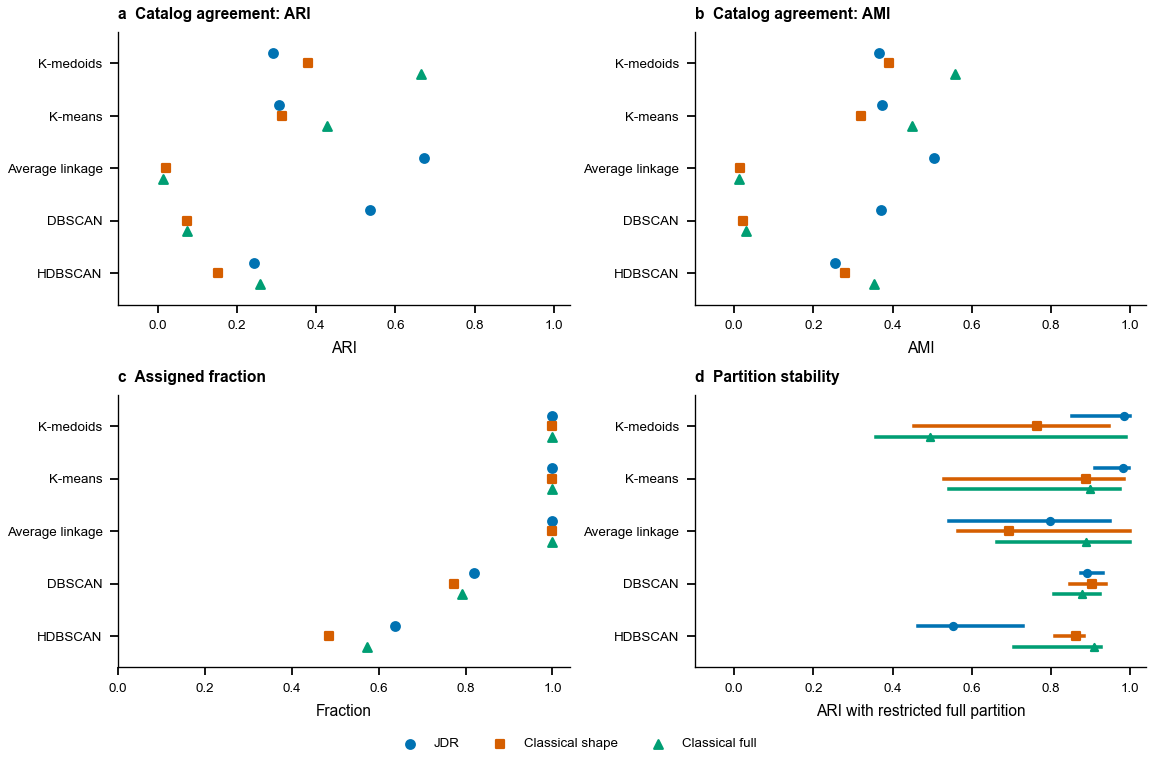

Figure 1 | Representation comparison with identical clustering policies on 1,000 original light curves. JDR is contrasted with 13 standardized classical shape features and those same features augmented by log period, log magnitude SD and log Q95−Q05 amplitude (16 total). ARI/AMI retain rejected points under label −1; coverage is shown separately. Stability intervals are empirical 10th–90th percentiles over 30 shared 800-star subsets, with median markers. Imputation and scaling are refitted inside every classical-feature subset. These are stability summaries, not confidence intervals, and no model is selected from the catalog scores. All matrix methods receive squared dissimilarities in the primary comparison.

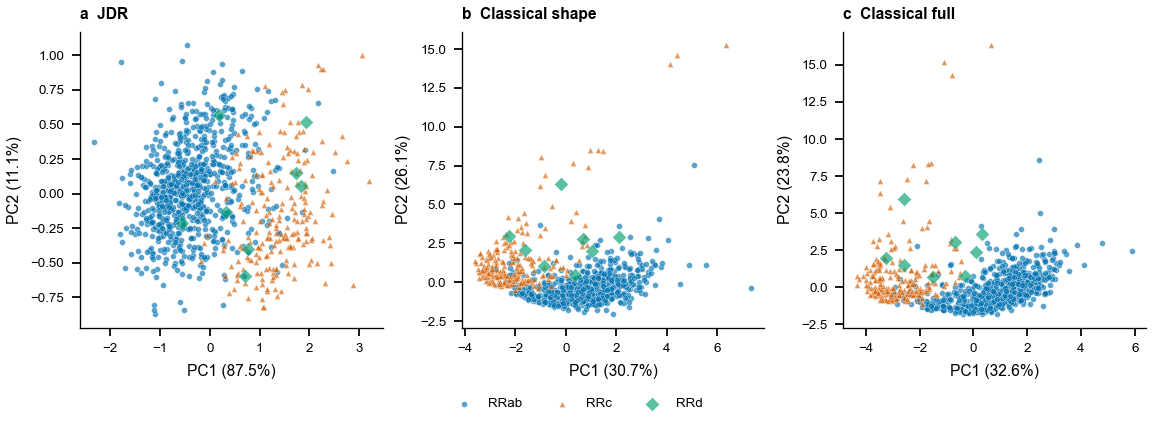

Figure 2 | Two-dimensional PCA views of the three representations. All 1,000 objects are shown, colored by catalog subtype with distinct markers; eight RRd stars cannot support rare-class inference. Each PCA is fitted separately; axes and explained-variance fractions refer to different spaces and are not directly comparable. Models use full representations, never these two coordinates. Dense point layers are rasterized at 600 dpi in vector exports.

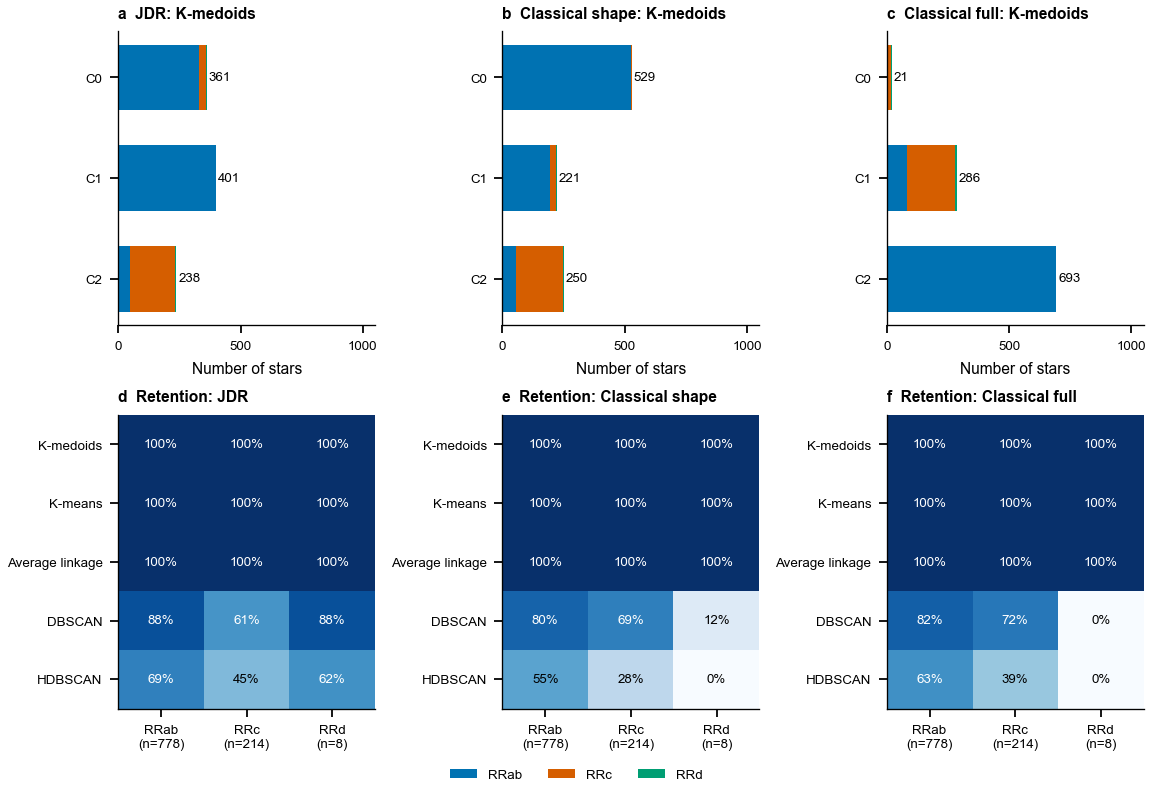

Figure 3 | Primary K-medoids composition and all-model retention. Top: counts in all three medoid clusters for each representation, with observed sizes; IDs are arbitrary across panels. Bottom: assigned fraction within each catalog subtype for every model, including all rejected stars in the denominator. All cluster compositions, including density-method noise, are exported in cluster_composition.csv. Fully assigned partitions need not recover astrophysical classes.

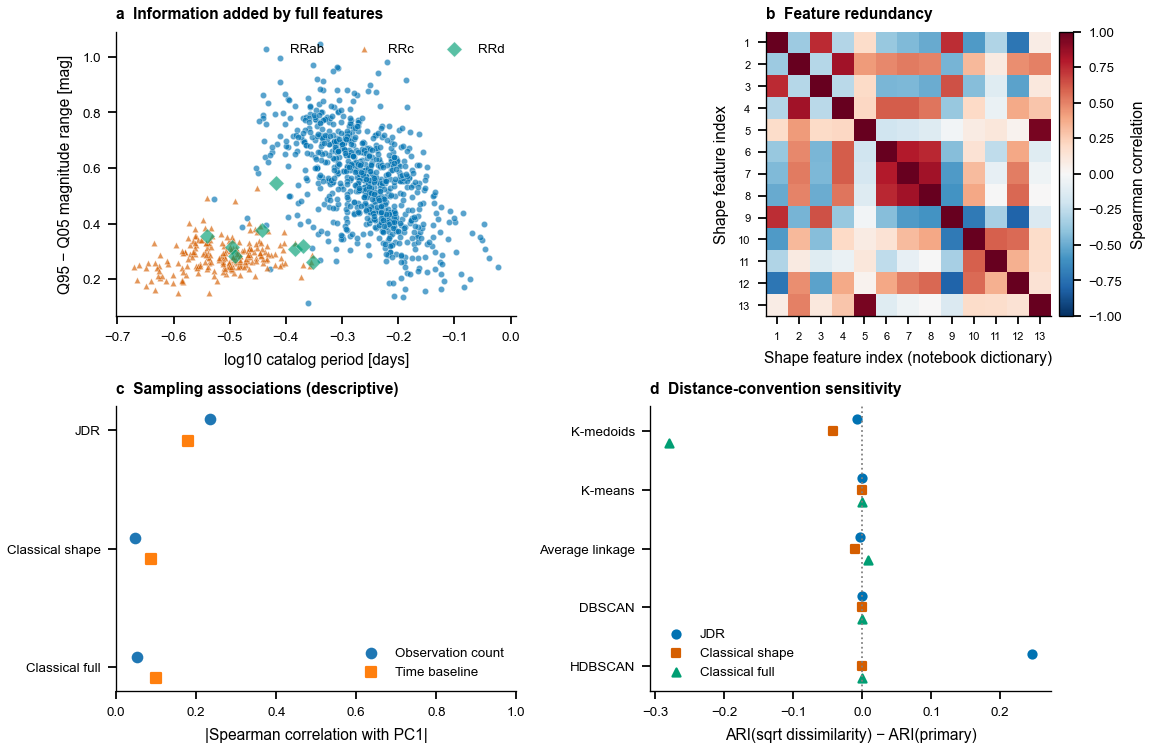

Figure 4 | Interpreting the representation comparison. a, Catalog period and robust magnitude range are additional scalar information in Classical full; JDR and Classical shape remove them as scalars. b, Spearman feature correlations indicate redundancy; feature indices follow the notebook dictionary. c, Absolute PC1 associations with observation count and time baseline are descriptive, not evidence of causal confounding. d, Change in all-star ARI when matrix methods receive square-root dissimilarities instead of their primary squared dissimilarities. K-means retains its full-vector squared objective. This predeclared sensitivity is not used to choose primary settings.

In [16]:
figure_dir=draw_figures(OUTPUT)
for stem,caption in json.loads((figure_dir/'captions.json').read_text()).items():
    display(Image(filename=str(figure_dir/f'{stem}_preview.png')))
    display(Markdown(caption))

## 10. Interpretation and reproducibility checklist

The comparison is descriptive and in-sample. Labels are reserved for evaluation, although selecting RR Lyrae subtypes and assuming K=3 are explicit prior knowledge. Catalog periods and epochs come from an existing curated catalog. Eight RRd objects cannot support generalization about rare-class recovery. Both representations can respond to observation cadence/noise; PC1 associations are descriptive and do not establish or rule out confounding. Fixed feature selection, robust scaling, correlated predictors, phase alignment and the narrow JDR band all affect the result. A future independent cohort and controlled cadence/noise simulations are needed for a scientific-superiority claim.

`classical_features.csv` stores unscaled features, `scalers.json` stores full-cohort transformations, and `subset_scalers.json` stores every subset's separately learned transformation. `cluster_labels.csv` retains every object and noise label. `comparison_arrays.npz` contains full embeddings, matrices, PCA coordinates and raw folded measurements indexed by numeric offsets; `allow_pickle=False` is sufficient. `subsample_membership.json` contains all shared subsets. The model, retention, composition, integral, sampling and convention-sensitivity CSVs are figure source data. Provenance records input/catalog hashes and numerical-library versions. The packaged notebook and code-cell hashes identify the actual implementation used.

To reproduce elsewhere, extract the bundle, create a Python 3.12 environment, install `environment-lock.txt`, then open this notebook and run every cell. Alternatively run the supplied `run_notebook.py` with that interpreter; it explicitly launches the same Python as its kernel. No repository `src/` files, earlier notebooks, network download or previous results are required. The source catalogs' credits remain applicable.

In [17]:
assert len(scores)==15 and len(stability)==3*5*30
assert (pd.read_csv(OUTPUT/'cluster_composition.csv').groupby(['representation','model'])['count'].sum()==1000).all()
assert json.loads((OUTPUT/'reproducibility.json').read_text())['arrays_identical']
display(pd.Series(json.loads((OUTPUT/'provenance.json').read_text())['versions'],name='Recorded environment').to_frame())
print('Completed self-contained comparison:',OUTPUT)

,Recorded environment
numpy,2.4.6
scipy,1.17.1
pandas,3.0.3
scikit-learn,1.8.0
matplotlib,3.10.9
astropy,8.0.1
threadpoolctl,3.6.0


Completed self-contained comparison: /Users/francisco/code/JDR-Python/results/representation_comparison_1000
